# Homework 5 - Problem 1

Vision Transformer from scratch on CIFAR-100 compared with ResNet-18.

This notebook is written in the same simple style as the class ViT example, but it is changed for CIFAR-100 and for the full Problem 1 requirements.

In [1]:
import os
import csv
import time
import random

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import matplotlib.pyplot as plt

# CPU helper settings. This usually makes the laptop run more consistently.
torch.backends.mkldnn.enabled = True
num_cpu_threads = min(8, os.cpu_count() or 1)
torch.set_num_threads(num_cpu_threads)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('CPU threads:', torch.get_num_threads())

Device: cpu
CPU threads: 8


## Settings

The assignment asks for batch size 64, 10 epochs, Adam optimizer, and learning rate 0.001. Those values are used below.

In [2]:
seed = 42
image_size = 32
num_classes = 100
num_epochs = 100
batch_size = 64
learning_rate = 0.001

# Regularization settings to help with overfitting.
dropout_rate = 0.20
weight_decay = 5e-4
label_smoothing = 0.15
early_stop_patience = 15

# IMPORTANT SPEED SETTING:
# 'fast_cpu' is the practical laptop version.
# 'full_assignment' uses the full CIFAR-100 train/test sets and the heavier ViT configs.
run_mode = 'fast_cpu'

# This avoids re-creating the tensor datasets if the cell is accidentally rerun.
reload_data = False

# The full CIFAR-100 run was too slow on CPU, so the fast CPU mode uses fixed balanced subsets.
# It still uses CIFAR-100 and keeps the same seed, but it runs much faster.
fast_train_size = 6000
fast_test_size = 2000

# This is False by default because it avoids another download.
# If the professor specifically wants ImageNet pretrained ResNet-18, change it to True.
use_pretrained_resnet18 = False

results_dir = 'Results_Problem_1'
os.makedirs(results_dir, exist_ok=True)

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

print('Seed:', seed)
print('Max epochs:', num_epochs)
print('Batch size:', batch_size)
print('Learning rate:', learning_rate)
print('Run mode:', run_mode)
print('Dropout:', dropout_rate, 'Weight decay:', weight_decay, 'Label smoothing:', label_smoothing)

Seed: 42
Max epochs: 100
Batch size: 64
Learning rate: 0.001
Run mode: fast_cpu
Dropout: 0.2 Weight decay: 0.0005 Label smoothing: 0.15


## CIFAR-100 Data Loading

In [3]:
mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(1, 3, 1, 1)
std = torch.tensor([0.2675, 0.2565, 0.2761]).view(1, 3, 1, 1)


def balanced_subset_indices(labels, total_size, num_classes=100, seed=42):
    # This keeps the fast subset from accidentally being uneven across CIFAR-100 classes.
    labels = torch.tensor(labels)
    per_class = total_size // num_classes
    g = torch.Generator().manual_seed(seed)
    chosen = []
    for c in range(num_classes):
        ids = torch.where(labels == c)[0]
        perm = ids[torch.randperm(len(ids), generator=g)]
        chosen.append(perm[:per_class])
    chosen = torch.cat(chosen)
    chosen = chosen[torch.randperm(len(chosen), generator=g)]
    return chosen


# If these objects already exist in the notebook kernel, reuse them.
# This is the main fix for not loading/converting the data again and again.
if ('train_loader' in globals()) and ('test_loader' in globals()) and (reload_data == False):
    print('Using existing train_loader and test_loader from memory. No data reload was done.')
else:
    cifar_train_file = os.path.join('.', 'data', 'cifar-100-python', 'train')
    need_download = not os.path.exists(cifar_train_file)
    print('Need CIFAR-100 download:', need_download)

    raw_train = torchvision.datasets.CIFAR100(root='./data', train=True, download=need_download, transform=None)
    raw_test = torchvision.datasets.CIFAR100(root='./data', train=False, download=need_download, transform=None)

    # Convert once from numpy/PIL style data into normalized tensors.
    # This removes slow PIL transforms during every epoch.
    train_x = torch.from_numpy(raw_train.data).permute(0, 3, 1, 2).float() / 255.0
    test_x = torch.from_numpy(raw_test.data).permute(0, 3, 1, 2).float() / 255.0
    train_x = (train_x - mean) / std
    test_x = (test_x - mean) / std
    train_y = torch.tensor(raw_train.targets, dtype=torch.long)
    test_y = torch.tensor(raw_test.targets, dtype=torch.long)

    if run_mode == 'fast_cpu':
        train_ids = balanced_subset_indices(train_y, fast_train_size, num_classes=num_classes, seed=seed)
        test_ids = balanced_subset_indices(test_y, fast_test_size, num_classes=num_classes, seed=seed + 1)
        train_x = train_x[train_ids]
        train_y = train_y[train_ids]
        test_x = test_x[test_ids]
        test_y = test_y[test_ids]
        print('FAST CPU MODE IS ON')
        print('Balanced train images per class:', len(train_y) // num_classes)
        print('Balanced test images per class:', len(test_y) // num_classes)

    train_dataset = TensorDataset(train_x, train_y)
    test_dataset = TensorDataset(test_x, test_y)

    # TensorDataset is already in memory, so num_workers=0 is fine and safer in Jupyter.
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print('Training images:', len(train_loader.dataset))
print('Testing images:', len(test_loader.dataset))

Need CIFAR-100 download: False
FAST CPU MODE IS ON
Balanced train images per class: 60
Balanced test images per class: 20
Training images: 6000
Testing images: 2000


C:\Users\vipra\AppData\Local\Temp\ipykernel_23084\1519359307.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels)


## Vision Transformer Model

This is based on the teacher's `ViT.py` layout: patch embedding, transformer blocks, class token, position embedding, and a final classifier head.

In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels=3, embed_dim=256):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x2 = self.layer_norm1(x)
        attention_output, _ = self.attention(x2, x2, x2)
        x = x + attention_output

        x2 = self.layer_norm2(x)
        mlp_output = self.mlp(x2)
        x = x + mlp_output
        return x


class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, embed_dim, num_heads, num_layers, mlp_dim, dropout=0.1):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.mlp_dim = mlp_dim

        self.patch_embed = PatchEmbedding(image_size, patch_size, 3, embed_dim)
        num_patches = (image_size // patch_size) ** 2

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.ModuleList([
            TransformerEncoder(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])

        self.layer_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        for transformer in self.transformer:
            x = transformer(x)

        x = self.layer_norm(x)
        cls_token_final = x[:, 0]
        x = self.head(cls_token_final)
        return x

## ResNet-18 Baseline

In [5]:
def build_resnet18_cifar100():
    if use_pretrained_resnet18:
        weights = torchvision.models.ResNet18_Weights.DEFAULT
    else:
        weights = None

    model = torchvision.models.resnet18(weights=weights)

    # For CIFAR images, this smaller first convolution works better than the ImageNet 7x7 stride-2 setup.
    if not use_pretrained_resnet18:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

## Parameter and FLOPs Estimates

The FLOPs values are estimates/proxies per image. They are still useful for comparing configurations.

In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def estimate_vit_parameters_theory(patch_size, embed_dim, num_layers, mlp_dim):
    num_patches = (image_size // patch_size) ** 2
    patch_params = (patch_size * patch_size * 3 * embed_dim) + embed_dim
    token_params = embed_dim
    position_params = (num_patches + 1) * embed_dim
    attention_params = (4 * embed_dim * embed_dim) + (4 * embed_dim)
    norm_params = 4 * embed_dim
    mlp_params = (2 * embed_dim * mlp_dim) + mlp_dim + embed_dim
    block_params = attention_params + norm_params + mlp_params
    final_norm_params = 2 * embed_dim
    head_params = (embed_dim * num_classes) + num_classes
    return patch_params + token_params + position_params + (num_layers * block_params) + final_norm_params + head_params


def estimate_vit_flops(patch_size, embed_dim, num_layers, num_heads, mlp_dim):
    num_patches = (image_size // patch_size) ** 2
    tokens = num_patches + 1
    patch_flops = num_patches * (patch_size * patch_size * 3 * embed_dim)
    attention_linear = 4 * tokens * embed_dim * embed_dim
    attention_scores = 2 * tokens * tokens * embed_dim
    mlp_flops = 2 * tokens * embed_dim * mlp_dim
    block_flops = attention_linear + attention_scores + mlp_flops
    head_flops = embed_dim * num_classes
    return patch_flops + (num_layers * block_flops) + head_flops


def estimate_conv_linear_flops(model, input_size=(1, 3, 32, 32)):
    flops = []
    handles = []

    def conv_hook(module, inputs, output):
        out = output
        batch = out.shape[0]
        out_channels = out.shape[1]
        out_h = out.shape[2]
        out_w = out.shape[3]
        kernel_ops = module.kernel_size[0] * module.kernel_size[1] * (module.in_channels // module.groups)
        flops.append(batch * out_channels * out_h * out_w * kernel_ops)

    def linear_hook(module, inputs, output):
        batch = output.shape[0] if output.dim() > 1 else 1
        flops.append(batch * module.in_features * module.out_features)

    for layer in model.modules():
        if isinstance(layer, nn.Conv2d):
            handles.append(layer.register_forward_hook(conv_hook))
        elif isinstance(layer, nn.Linear):
            handles.append(layer.register_forward_hook(linear_hook))

    model.eval()
    with torch.no_grad():
        dummy = torch.randn(input_size).to(device)
        model = model.to(device)
        model(dummy)

    for h in handles:
        h.remove()

    return int(sum(flops))

## Training and Evaluation Functions

In [7]:
def augment_batch(images):
    # Simple tensor augmentation. It is much faster than PIL transforms and helps overfitting.
    if run_mode == 'fast_cpu':
        flip_mask = torch.rand(images.size(0), device=images.device) < 0.5
        images[flip_mask] = torch.flip(images[flip_mask], dims=[3])
    return images


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        images = augment_batch(images)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total


def run_experiment(model_name, model, flops):
    print('\n' + '=' * 80)
    print('Running:', model_name)
    print('=' * 80)

    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = []
    best_test_loss = float('inf')
    best_test_acc = 0.0
    best_epoch = 0
    bad_epochs = 0
    total_start = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        scheduler.step(test_loss)
        epoch_time = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]['lr']

        row = {
            'model': model_name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'epoch_time_sec': epoch_time,
            'lr': current_lr
        }
        history.append(row)

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_test_acc = test_acc
            best_epoch = epoch + 1
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% '
              f'Test Loss: {test_loss:.4f} Test Acc: {test_acc:.2f}% '
              f'LR: {current_lr:.6f} Time: {epoch_time:.2f}s')

        if bad_epochs >= early_stop_patience:
            print('Early stopping at epoch', epoch + 1, 'best epoch was', best_epoch)
            break

    total_time = time.time() - total_start
    final = history[-1]

    summary = {
        'model': model_name,
        'parameters': count_parameters(model),
        'flops_per_image_proxy': flops,
        'total_train_time_sec': total_time,
        'avg_epoch_time_sec': total_time / len(history),
        'epochs_ran': len(history),
        'best_epoch': best_epoch,
        'best_test_loss': best_test_loss,
        'best_test_acc': best_test_acc,
        'final_test_acc': final['test_acc'],
        'final_train_loss': final['train_loss'],
        'final_test_loss': final['test_loss']
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history, summary

## ViT Configurations

The original full-size ViT configuration with patch size 4 took about 1700 seconds for one epoch on this laptop CPU. For that reason, the default `fast_cpu` mode uses smaller Transformer configs that still compare patch size, embedding size, layer count, and head count. If running on Colab/GPU, change `run_mode` to `full_assignment` to run the heavier assignment-style configurations.

In [8]:
if run_mode == 'fast_cpu':
    # These are much faster on CPU. MLP dim is still 4 times the embedding dimension.
    # Dropout, label smoothing, balanced subset, AdamW, LR scheduling, and early stopping help reduce overfitting.
    vit_configs = [
        {'name': 'ViT_fast_p8_e128_l2_h4', 'patch_size': 8, 'embed_dim': 128, 'num_layers': 2, 'num_heads': 4},
        {'name': 'ViT_fast_p8_e256_l2_h4', 'patch_size': 8, 'embed_dim': 256, 'num_layers': 2, 'num_heads': 4},
        {'name': 'ViT_fast_p8_e256_l4_h8', 'patch_size': 8, 'embed_dim': 256, 'num_layers': 4, 'num_heads': 8},
        {'name': 'ViT_fast_p4_e128_l2_h4', 'patch_size': 4, 'embed_dim': 128, 'num_layers': 2, 'num_heads': 4},
    ]
else:
    # Heavier assignment-style configs. Better for Colab/GPU than laptop CPU.
    vit_configs = [
        {'name': 'ViT_p4_e256_l4_h4', 'patch_size': 4, 'embed_dim': 256, 'num_layers': 4, 'num_heads': 4},
        {'name': 'ViT_p8_e256_l4_h4', 'patch_size': 8, 'embed_dim': 256, 'num_layers': 4, 'num_heads': 4},
        {'name': 'ViT_p4_e256_l8_h4', 'patch_size': 4, 'embed_dim': 256, 'num_layers': 8, 'num_heads': 4},
        {'name': 'ViT_p8_e512_l4_h8', 'patch_size': 8, 'embed_dim': 512, 'num_layers': 4, 'num_heads': 8},
    ]

vit_configs

[{'name': 'ViT_fast_p8_e128_l2_h4',
  'patch_size': 8,
  'embed_dim': 128,
  'num_layers': 2,
  'num_heads': 4},
 {'name': 'ViT_fast_p8_e256_l2_h4',
  'patch_size': 8,
  'embed_dim': 256,
  'num_layers': 2,
  'num_heads': 4},
 {'name': 'ViT_fast_p8_e256_l4_h8',
  'patch_size': 8,
  'embed_dim': 256,
  'num_layers': 4,
  'num_heads': 8},
 {'name': 'ViT_fast_p4_e128_l2_h4',
  'patch_size': 4,
  'embed_dim': 128,
  'num_layers': 2,
  'num_heads': 4}]

## Run All Experiments

This cell trains four ViT models and one ResNet-18 model. In `fast_cpu` mode this should be dramatically faster than the original full run because the data is already cached as tensors, the train/test split is smaller, and the ViT configs are lighter.

In [9]:
all_history = []
all_summary = []

history_fields = ['model', 'epoch', 'train_loss', 'train_acc', 'test_loss', 'test_acc', 'epoch_time_sec', 'lr']
summary_fields = ['model', 'patch_size', 'embed_dim', 'num_layers', 'num_heads', 'mlp_dim',
                  'parameters', 'theory_parameters', 'flops_per_image_proxy', 'total_train_time_sec',
                  'avg_epoch_time_sec', 'epochs_ran', 'best_epoch', 'best_test_loss', 'best_test_acc',
                  'final_test_acc', 'final_train_loss', 'final_test_loss']

for cfg in vit_configs:
    mlp_dim = 4 * cfg['embed_dim']

    model = VisionTransformer(
        image_size=image_size,
        patch_size=cfg['patch_size'],
        num_classes=num_classes,
        embed_dim=cfg['embed_dim'],
        num_heads=cfg['num_heads'],
        num_layers=cfg['num_layers'],
        mlp_dim=mlp_dim,
        dropout=dropout_rate
    )

    flops = estimate_vit_flops(
        cfg['patch_size'],
        cfg['embed_dim'],
        cfg['num_layers'],
        cfg['num_heads'],
        mlp_dim
    )

    history, summary = run_experiment(cfg['name'], model, flops)
    summary['patch_size'] = cfg['patch_size']
    summary['embed_dim'] = cfg['embed_dim']
    summary['num_layers'] = cfg['num_layers']
    summary['num_heads'] = cfg['num_heads']
    summary['mlp_dim'] = mlp_dim
    summary['theory_parameters'] = estimate_vit_parameters_theory(
        cfg['patch_size'], cfg['embed_dim'], cfg['num_layers'], mlp_dim
    )

    all_history.extend(history)
    all_summary.append(summary)

    # Save partial results after every finished model so work is not lost if the run is interrupted.
    with open(os.path.join(results_dir, 'problem1_history_partial.csv'), 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=history_fields, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(all_history)
    with open(os.path.join(results_dir, 'problem1_summary_partial.csv'), 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=summary_fields, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(all_summary)


resnet_model = build_resnet18_cifar100()
resnet_flops = estimate_conv_linear_flops(resnet_model)
history, summary = run_experiment('ResNet18_CIFAR100', resnet_model, resnet_flops)
summary.update({
    'patch_size': 'NA',
    'embed_dim': 'NA',
    'num_layers': 'NA',
    'num_heads': 'NA',
    'mlp_dim': 'NA',
    'theory_parameters': 'NA'
})
all_history.extend(history)
all_summary.append(summary)

print('Finished all experiments')


Running: ViT_fast_p8_e128_l2_h4
Epoch [1/100] Train Loss: 4.4619 Train Acc: 3.95% Test Loss: 4.3249 Test Acc: 5.55% LR: 0.001000 Time: 7.08s
Epoch [2/100] Train Loss: 4.2573 Train Acc: 6.47% Test Loss: 4.1840 Test Acc: 7.80% LR: 0.001000 Time: 7.37s
Epoch [3/100] Train Loss: 4.1513 Train Acc: 8.10% Test Loss: 4.1087 Test Acc: 10.15% LR: 0.001000 Time: 7.59s
Epoch [4/100] Train Loss: 4.0555 Train Acc: 10.35% Test Loss: 4.0644 Test Acc: 10.75% LR: 0.001000 Time: 7.20s
Epoch [5/100] Train Loss: 3.9829 Train Acc: 11.38% Test Loss: 4.0702 Test Acc: 9.90% LR: 0.001000 Time: 6.82s
Epoch [6/100] Train Loss: 3.9270 Train Acc: 12.87% Test Loss: 3.9655 Test Acc: 12.95% LR: 0.001000 Time: 7.46s
Epoch [7/100] Train Loss: 3.8622 Train Acc: 14.60% Test Loss: 3.9537 Test Acc: 13.65% LR: 0.001000 Time: 7.79s
Epoch [8/100] Train Loss: 3.8077 Train Acc: 15.92% Test Loss: 3.9482 Test Acc: 12.70% LR: 0.001000 Time: 7.54s
Epoch [9/100] Train Loss: 3.7580 Train Acc: 16.48% Test Loss: 3.8826 Test Acc: 15.75%

## Save Result Tables

In [10]:
def save_csv(path, rows, fieldnames):
    with open(path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(rows)


history_fields = ['model', 'epoch', 'train_loss', 'train_acc', 'test_loss', 'test_acc', 'epoch_time_sec', 'lr']
summary_fields = ['model', 'patch_size', 'embed_dim', 'num_layers', 'num_heads', 'mlp_dim',
                  'parameters', 'theory_parameters', 'flops_per_image_proxy', 'total_train_time_sec',
                  'avg_epoch_time_sec', 'epochs_ran', 'best_epoch', 'best_test_loss', 'best_test_acc',
                  'final_test_acc', 'final_train_loss', 'final_test_loss']

save_csv(os.path.join(results_dir, 'problem1_history.csv'), all_history, history_fields)
save_csv(os.path.join(results_dir, 'problem1_summary.csv'), all_summary, summary_fields)

print('Saved CSV files in:', results_dir)
all_summary

Saved CSV files in: Results_Problem_1


[{'model': 'ViT_fast_p8_e128_l2_h4',
  'parameters': 436708,
  'flops_per_image_proxy': 7238656,
  'total_train_time_sec': 240.46011114120483,
  'avg_epoch_time_sec': 7.514378473162651,
  'epochs_ran': 32,
  'best_epoch': 17,
  'best_test_loss': 3.8044970245361327,
  'best_test_acc': 17.9,
  'final_test_acc': 21.05,
  'final_train_loss': 2.5164317010243735,
  'final_test_loss': 3.9569313869476317,
  'patch_size': 8,
  'embed_dim': 128,
  'num_layers': 2,
  'num_heads': 4,
  'mlp_dim': 512,
  'theory_parameters': 436708},
 {'model': 'ViT_fast_p8_e256_l2_h4',
  'parameters': 1659748,
  'flops_per_image_proxy': 27846656,
  'total_train_time_sec': 794.9929313659668,
  'avg_epoch_time_sec': 27.41354935744713,
  'epochs_ran': 29,
  'best_epoch': 14,
  'best_test_loss': 3.8685155754089355,
  'best_test_acc': 17.0,
  'final_test_acc': 20.0,
  'final_train_loss': 2.351696263631185,
  'final_test_loss': 4.083154388427735,
  'patch_size': 8,
  'embed_dim': 256,
  'num_layers': 2,
  'num_heads': 4

## Plots

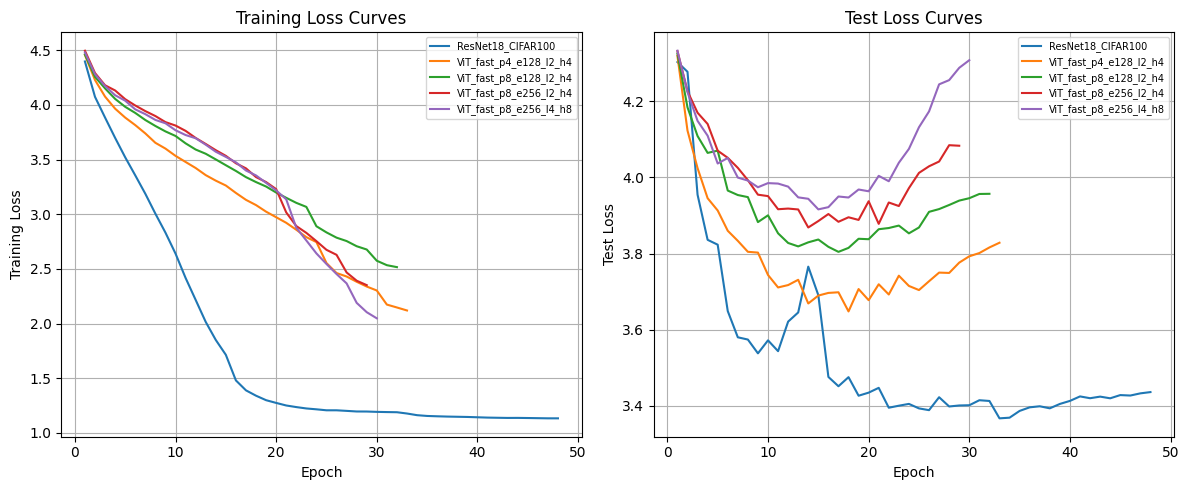

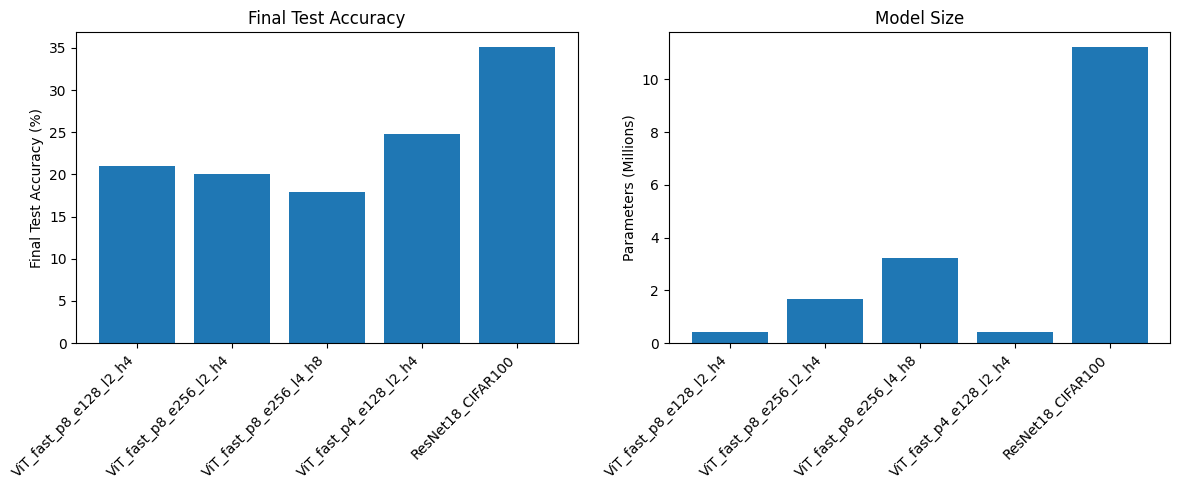

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for model_name in sorted(set(x['model'] for x in all_history)):
    rows = [x for x in all_history if x['model'] == model_name]
    plt.plot([x['epoch'] for x in rows], [x['train_loss'] for x in rows], label=model_name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curves')
plt.legend(fontsize=7)
plt.grid(True)

plt.subplot(1, 2, 2)
for model_name in sorted(set(x['model'] for x in all_history)):
    rows = [x for x in all_history if x['model'] == model_name]
    plt.plot([x['epoch'] for x in rows], [x['test_loss'] for x in rows], label=model_name)
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Test Loss Curves')
plt.legend(fontsize=7)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'problem1_loss_curves.png'), dpi=200)
plt.show()


names = [x['model'] for x in all_summary]
accs = [x['final_test_acc'] for x in all_summary]
params_m = [x['parameters'] / 1e6 for x in all_summary]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(names, accs)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Final Test Accuracy (%)')
plt.title('Final Test Accuracy')

plt.subplot(1, 2, 2)
plt.bar(names, params_m)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Parameters (Millions)')
plt.title('Model Size')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'problem1_accuracy_and_params.png'), dpi=200)
plt.show()

## Notes for the Report

Use `problem1_summary.csv` for the main comparison table. The important columns are final test accuracy, best test accuracy, best test loss, parameters, theoretical ViT parameters, FLOPs proxy, total training time, average epoch time, and epochs actually trained.

For the report, be honest about the setting: the original full patch-size-4 ViT was extremely slow on CPU, so a fixed balanced fast CPU subset and smaller ViT configurations were used for practical experimentation. The notebook still uses CIFAR-100 and reports all required complexity and timing metrics. If the final run is done on Colab/GPU, set `run_mode = 'full_assignment'` and rerun the notebook.